In [1]:

import pandas as pd
import matplotlib.pyplot as plt

frequency = pd.read_csv('freMTPLfreq.csv')

severity = pd.read_csv('freMTPLsev.csv')

severity_total = severity.groupby("PolicyID")["ClaimAmount"].sum().sort_index()

completedf = frequency.merge(severity_total, how="left",on="PolicyID")

completedf["AverageClaimAmount"] = completedf["ClaimAmount"] / completedf["ClaimNb"]

completedf = completedf.fillna(0)
#I checked and saw that there is no other missing values besides those formed from the left join
policyincident = completedf[completedf["ClaimNb"]>0]

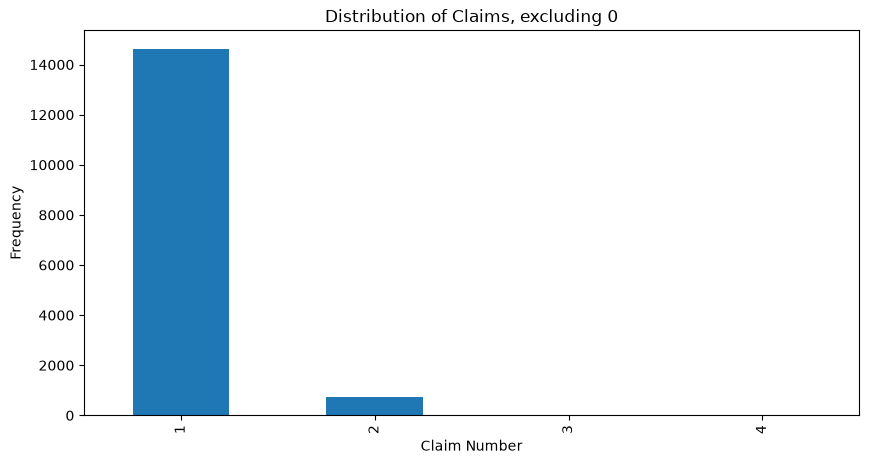

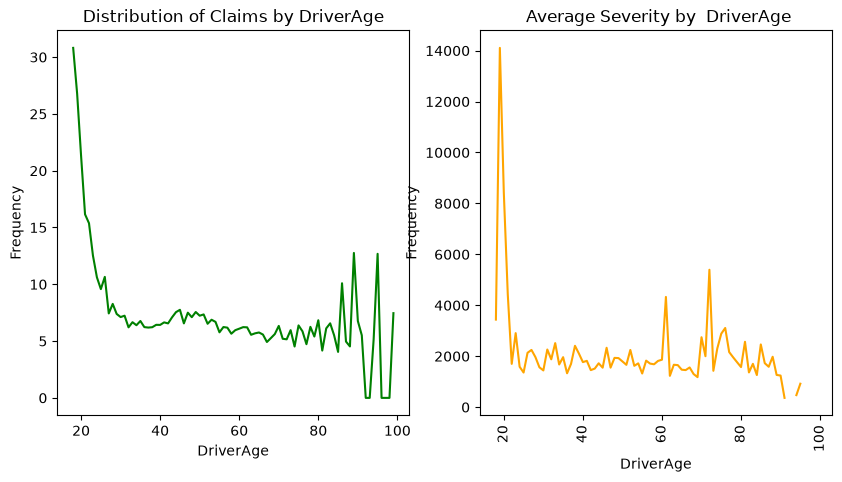

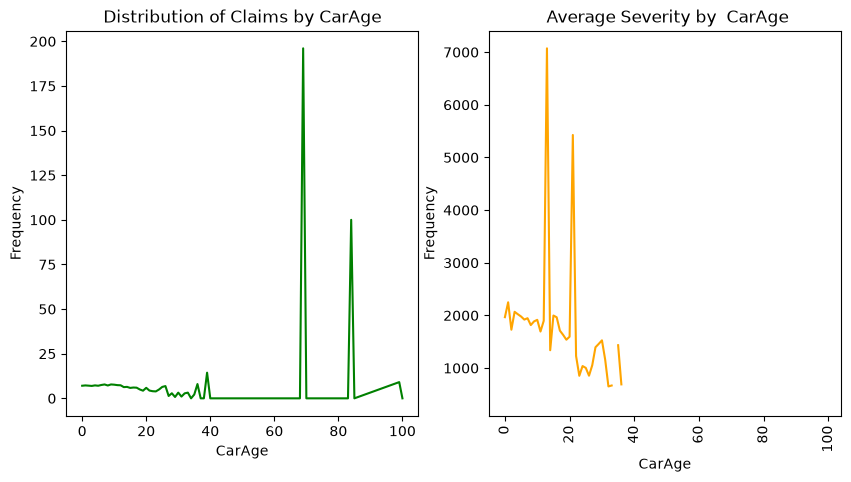

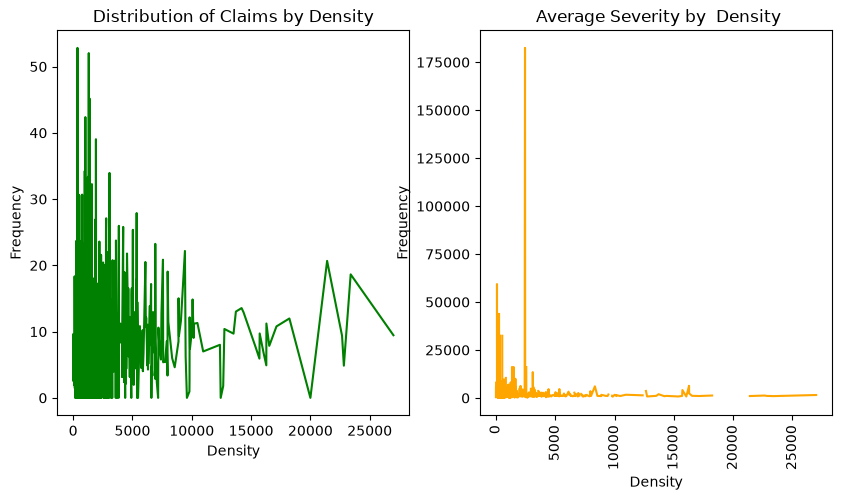

In [ ]:
#Understnading the data

len(policyincident)/len(frequency)

# Shows that only 3% of people have claims.

claimsdist =frequency["ClaimNb"].value_counts()
claimsdist = claimsdist[claimsdist.index >0]

plt.figure(figsize=(10, 5))
claimsdist.plot(kind='bar')
plt.xlabel("Claim Number")
plt.ylabel("Frequency")
plt.title("Distribution of Claims, excluding 0")
plt.show()
 
def claim_frequency_calc(df,col):
    summary = df.groupby(col).agg( claims= ("ClaimNb","sum"),exposure = ("Exposure","sum"),severity=("ClaimAmount", "sum"))
    summary["claim_frequency"] = summary["claims"] / summary["exposure"]
    summary["claim_frequency_per_100"] = summary["claim_frequency"]*100
    summary["average_claim_amount"] = summary["severity"] / summary["claims"]
    return summary

def claim_frequency_calc_groups(df,col,bins = 15):
    df_copy = df.copy()
    df_copy["groups"] = pd.cut(df[col],bins = bins)

    summary = df_copy.groupby("groups").agg( claims= ("ClaimNb","sum"),exposure = ("Exposure","sum"),severity=("ClaimAmount", "sum"))
    summary["claim_frequency"] = summary["claims"] / summary["exposure"]
    summary["claim_frequency_per_100"] = summary["claim_frequency"]*100
    summary["average_claim_amount"] = summary["severity"] / summary["claims"]
    return summary

cols_cts = ["DriverAge","CarAge","Density"]

col_dist = ["Brand","Gas","Power","Region"]

# was taking too long to load so decided to preload the data before running it



cols_cts = ["DriverAge","CarAge","Density"]

col_dist = ["Brand","Gas","Power","Region"]

def basic_eda_claims(col):
    relavent_var = claim_frequency_calc(completedf,col)
    fig, (ax1,ax2) = plt.subplots(1,2,figsize=(10, 5))
    if col in cols_cts:
        relavent_var["claim_frequency_per_100"].plot(kind='line', color='green',ax = ax1)
    else: 
        relavent_var["claim_frequency_per_100"].plot(kind='bar', color='purple',ax = ax1)
    ax1.set_xlabel(col)
    ax1.set_ylabel("Frequency")
    ax1.set_title("Distribution of Claims by " + col)

    if col in cols_cts:
        # summary = completedf.groupby(col).agg( claims= ("ClaimNb","sum"), severity= ("ClaimAmount","sum")).reset_index()
        # summary["AverageClaimAmount"] = summary["severity"] / summary["claims"]
        # summary = summary.sort_values(col)

        severity_agg = completedf.groupby(col).agg(severity = ("ClaimAmount","sum"))
        relavent_var["severity"] = severity_agg["severity"]
        relavent_var["AverageClaimAmount"] = relavent_var["severity"]/ relavent_var["claims"]
        relavent_var_sorted = relavent_var.sort_index()


        ax2.plot(relavent_var_sorted.index,relavent_var["AverageClaimAmount"],color = "orange")


    else:
        ax2.bar(completedf[col],completedf["AverageClaimAmount"])
    ax2.set_xlabel(col)
    ax2.set_ylabel("Frequency")
    ax2.set_title(" Average Severity by  " + col)
    plt.xticks(rotation = 90)
    plt.show()


col_name = cols_cts + col_dist

for col in col_name:
    basic_eda_claims(col)

#brief observations are that most collisions are caused by younger drivers,as cars get older there claim frequency spikes at two location besides that there is no general trend suggesting its an outlier
#there seems to be a negative correlation between density and claim frequency but there is a lot of noice and it is unclear if its accurate
#could be related to less infastructure such as lights and clear road signs leading to higher incresaes in accidents such as on country lanes

#it does not look like anything significant for car brands 
#there is an increase in the gas , the power and certain regions are more likely than others

# def basic_eda_severity_dist(col):
#     plt.figure(figsize=(10, 5))
#     plt.bar(policyincident[col],policyincident["AverageClaimAmount"])
#     plt.xlabel(col)
#     plt.ylabel("Frequency")
#     plt.title("Distribution of Claims by " + col)
#     plt.show()
    
# for col in cols_cts:
#     basic_eda_severity_dist(col)

Calculating summaries...
Done! Starting plots...


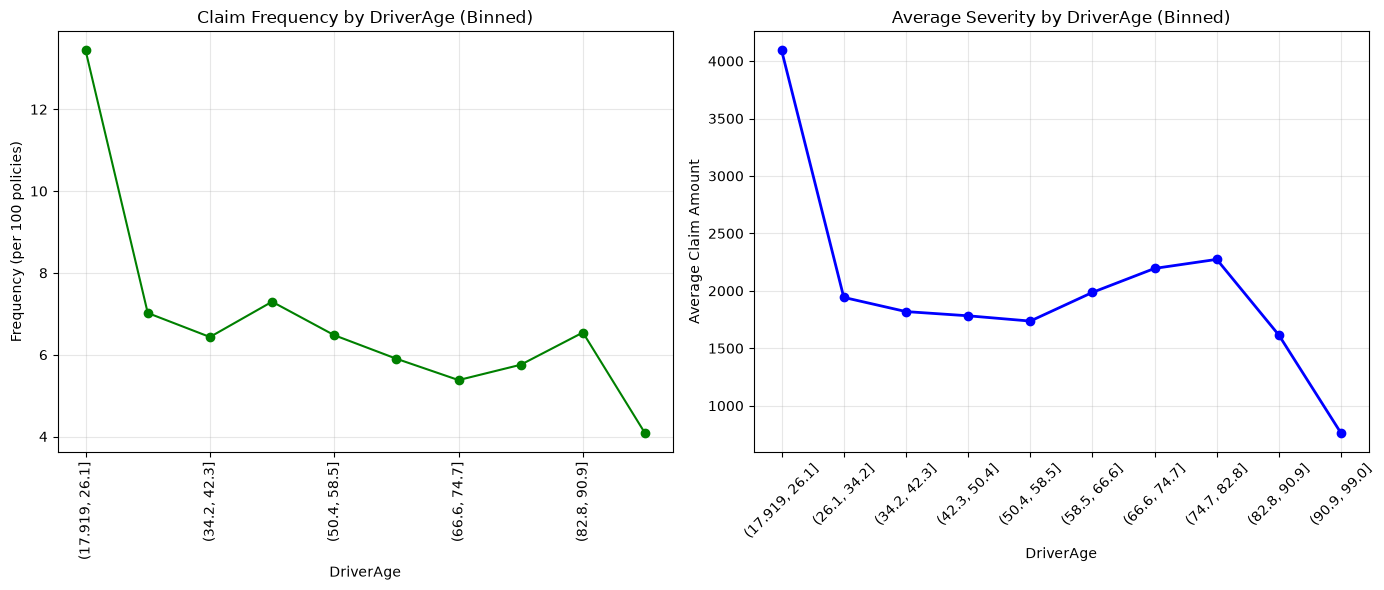

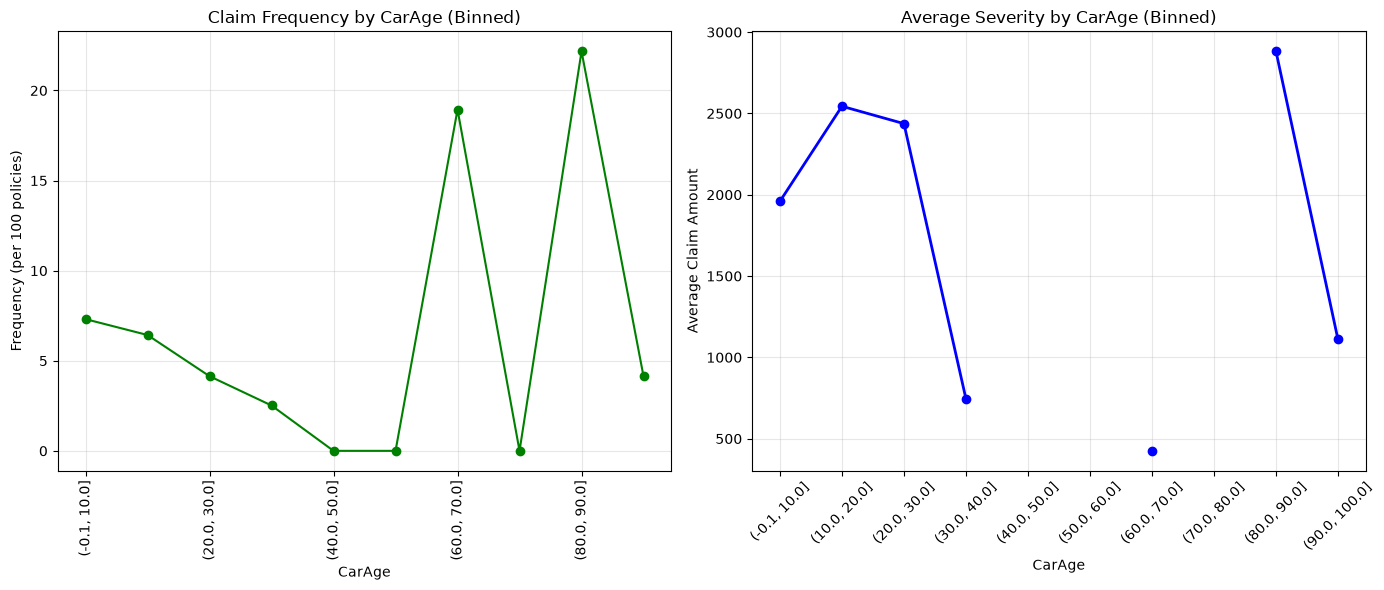

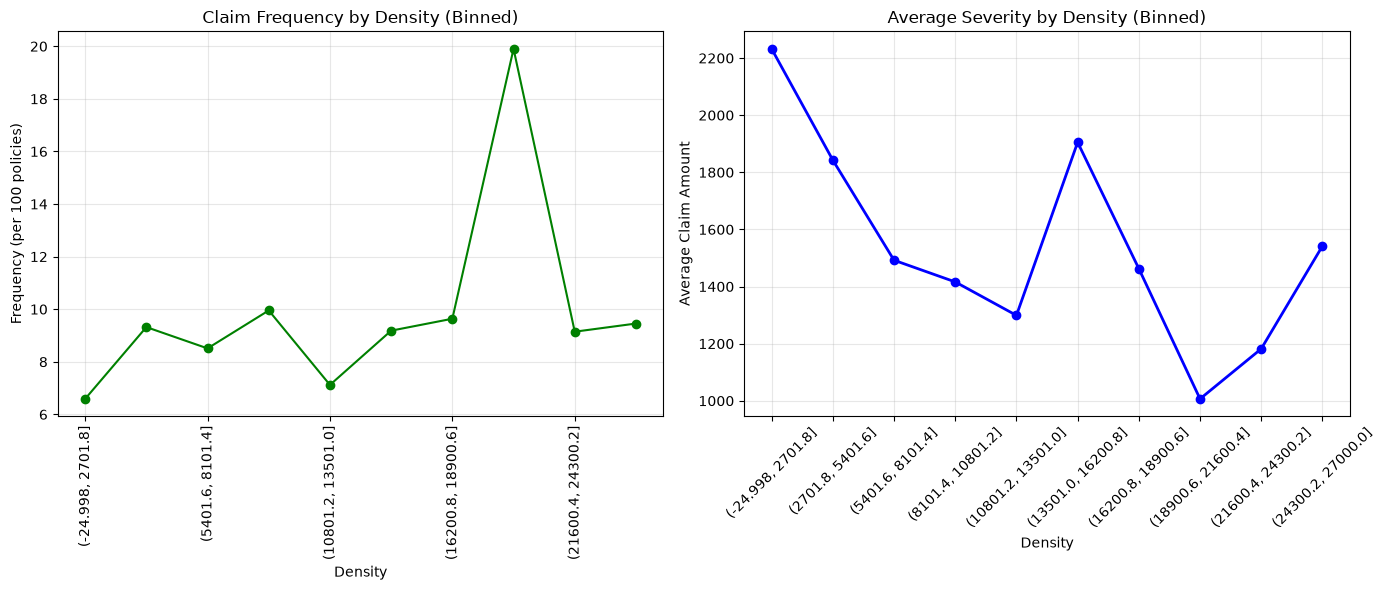

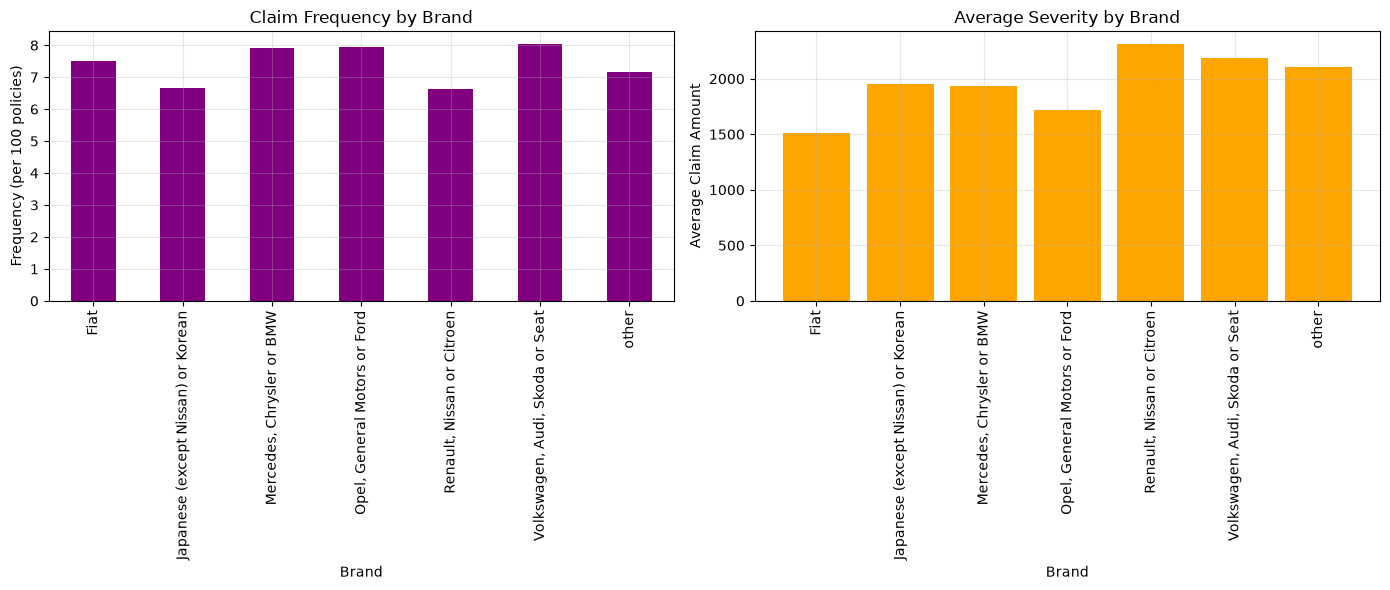

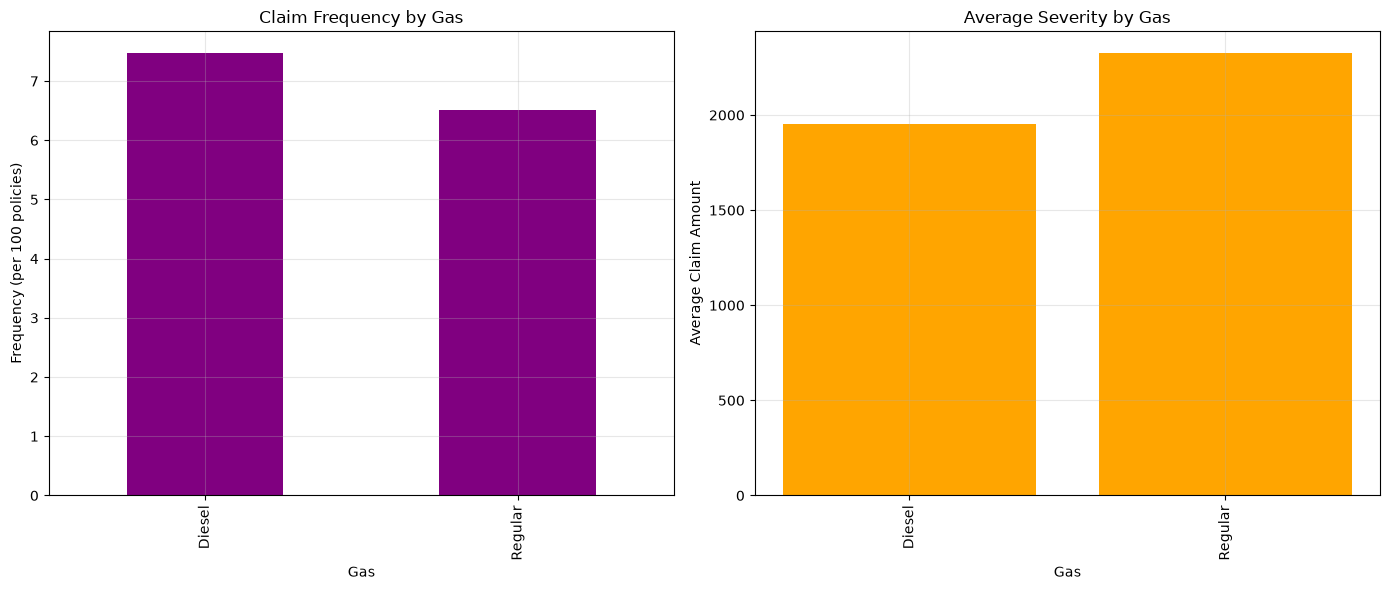

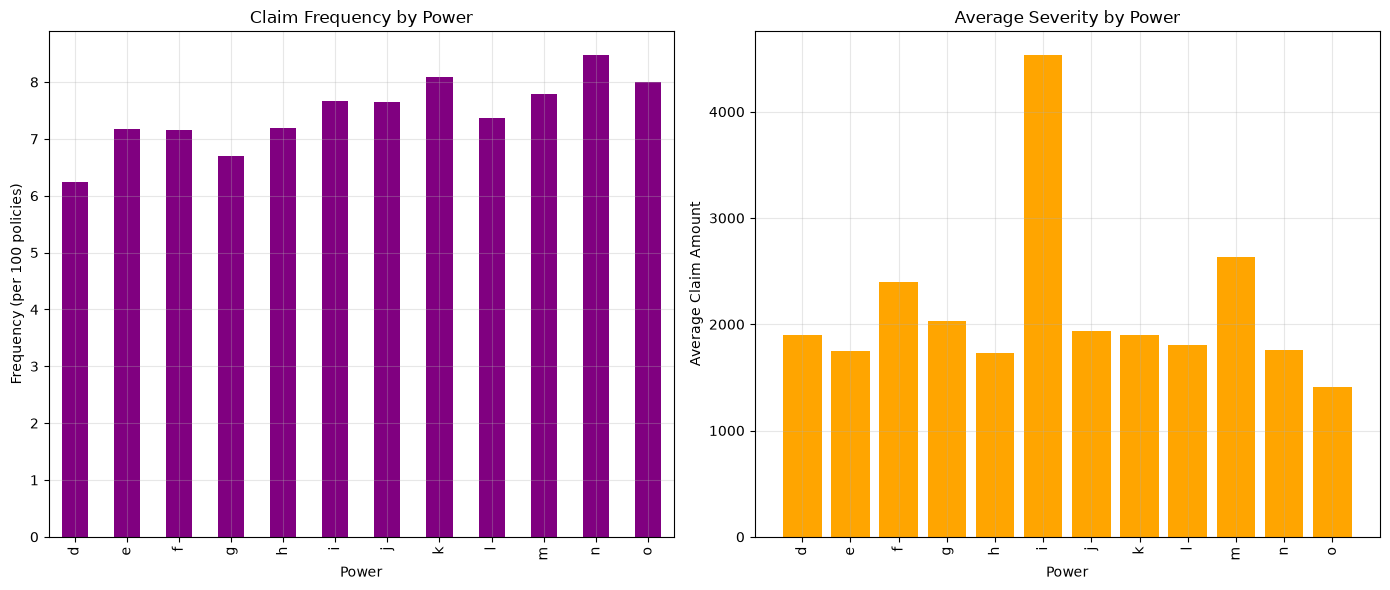

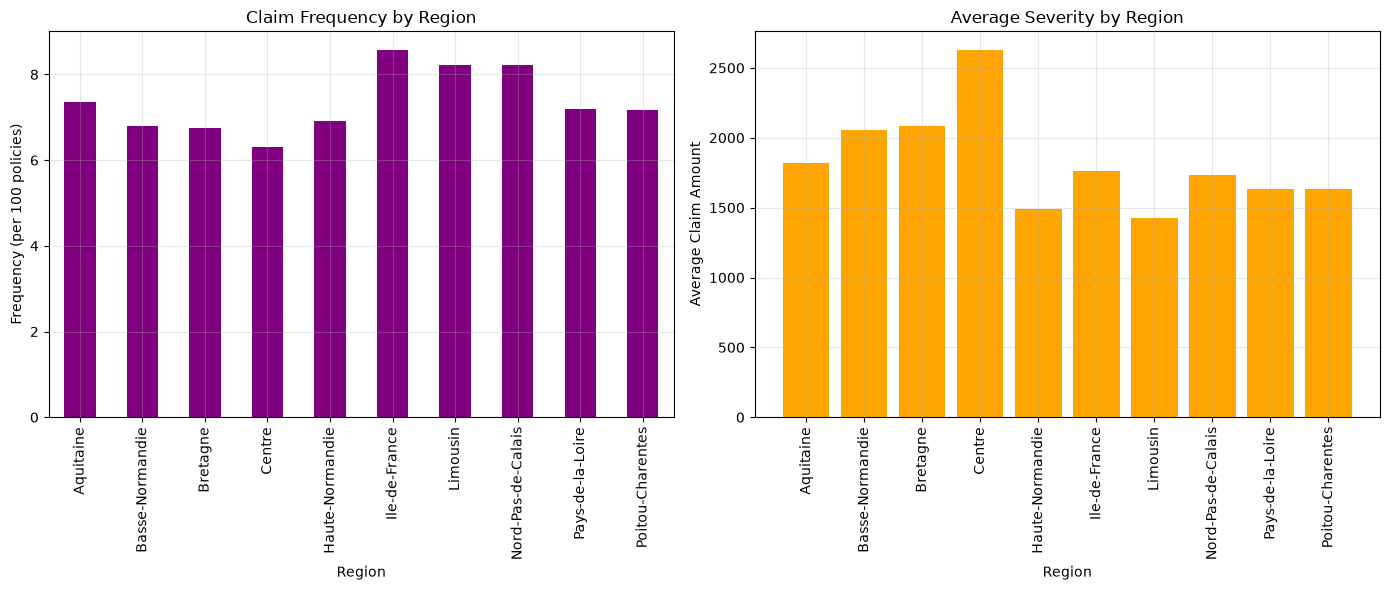

In [ ]:
cols_cts = ["DriverAge","CarAge","Density"]

col_dist = ["Brand","Gas","Power","Region"]

col_name = cols_cts + col_dist



def basic_eda_claims(col):

    
    relavent_var = claim_frequency_calc_groups(completedf,col)
    fig, (ax1,ax2) = plt.subplots(1,2,figsize=(10, 5))
    if col in cols_cts:
        relavent_var["claim_frequency_per_100"].plot(kind='line', color='green',ax = ax1)
    else: 
        relavent_var["claim_frequency_per_100"].plot(kind='bar', color='purple',ax = ax1)
    ax1.set_xlabel(col)
    ax1.set_ylabel("Frequency")
    ax1.set_title("Distribution of Claims by " + col)

    if col in cols_cts:
        # summary = completedf.groupby(col).agg( claims= ("ClaimNb","sum"), severity= ("ClaimAmount","sum")).reset_index()
        # summary["AverageClaimAmount"] = summary["severity"] / summary["claims"]
        # summary = summary.sort_values(col)

        severity_agg = completedf.groupby(col).agg(severity = ("ClaimAmount","sum"))
        relavent_var["severity"] = severity_agg["severity"]
        relavent_var["AverageClaimAmount"] = relavent_var["severity"]/ relavent_var["claims"]
        relavent_var_sorted = relavent_var.sort_index()


        ax2.plot(relavent_var_sorted.index,relavent_var["AverageClaimAmount"],color = "orange")


    else:
        ax2.bar(completedf[col],completedf["AverageClaimAmount"])
    ax2.set_xlabel(col)
    ax2.set_ylabel("Frequency")
    ax2.set_title(" Average Severity by  " + col)
    plt.xticks(rotation = 90)
    plt.show()





# Pre-calculate with correct function per column type
def precalculate_all(df, columns):
    summaries = {}
    for col in columns:
        if col in cols_cts:
            # Use BINNED version for continuous
            summaries[col] = claim_frequency_calc_binned(df, col, bins=10)
        else:
            # Use REGULAR version for discrete
            summaries[col] = claim_frequency_calc(df, col)
    return summaries

# Pre-calculate everything once
print("Calculating summaries...")
all_summaries = precalculate_all(completedf, col_name)
print("Done! Starting plots...")

def basic_eda_claims(col):
    relavent_var = all_summaries[col]  # Already binned or not
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
    
    # Plot 1: Frequency
    if col in cols_cts:
        # Binned data - line plot shows trend
        relavent_var["claim_frequency_per_100"].plot(
            kind='line', color='green', marker='o', ax=ax1
        )
        ax1.set_title(f"Claim Frequency by {col} (Binned)")
    else:
        # Discrete data - bar chart
        relavent_var["claim_frequency_per_100"].plot(
            kind='bar', color='purple', ax=ax1
        )
        ax1.set_title(f"Claim Frequency by {col}")
    
    ax1.set_xlabel(col)
    ax1.set_ylabel("Frequency (per 100 policies)")
    ax1.tick_params(axis='x', rotation=90)
    ax1.grid(True, alpha=0.3)
    
    # Plot 2: Average Severity
    if col in cols_cts:
        # Binned data - line plot for trend
        relavent_var_sorted = relavent_var.sort_index()
        ax2.plot(
            relavent_var_sorted.index.astype(str),  # Convert bins to strings for display
            relavent_var_sorted["AverageClaimAmount"],
            color='blue', marker='o', linewidth=2
        )
        ax2.set_title(f"Average Severity by {col} (Binned)")
        ax2.tick_params(axis='x', rotation=45)
    else:
        # Discrete data - bar chart
        ax2.bar(
            relavent_var.index,
            relavent_var["AverageClaimAmount"],
            color='orange'
        )
        ax2.set_title(f"Average Severity by {col}")
        ax2.tick_params(axis='x', rotation=90)
    
    ax2.set_xlabel(col)
    ax2.set_ylabel("Average Claim Amount")
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# Loop through all columns
for col in col_name:
    basic_eda_claims(col)